<center> <h1> Face Mask Detection Project </h1> </center>

In [1]:
#Import the dataset:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

100%|███████████████████████████████████████████████████████████████████████████████| 163M/163M [00:52<00:00, 3.28MB/s]

Extracting files...


Path to dataset files: C:\Users\Lenovo\.cache\kagglehub\datasets\omkargurav\face-mask-dataset\versions\1


In [1]:
#Import the dependencies:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split

In [3]:
with_mask_files = os.listdir("data/with_mask")
without_mask_files = os.listdir("data/without_mask")

print("Number of:")
print("\t\t With Mask Images = ",len(with_mask_files))
print("\t\t Without Mask Images = ",len(without_mask_files))

Number of:
		 With Mask Images =  3725
		 Without Mask Images =  3828


In [4]:
#Create labels for both classes of images:
### With mask = 1
### Without mask = 0


with_mask_labels = [1]*len(with_mask_files)
without_mask_labels = [0]*len(without_mask_files)

In [5]:
#Labels to first 5 images with masks:
with_mask_labels[:5]

[1, 1, 1, 1, 1]

In [8]:
#Labels to last 5 images without masks:
without_mask_labels[-5:]

[0, 0, 0, 0, 0]

In [10]:
print("Number of:")
print("\t\t With Mask Images = ",len(with_mask_labels))
print("\t\t Without Mask Images = ",len(without_mask_labels))


labels = with_mask_labels + without_mask_labels
print(len(labels))

Number of:
		 With Mask Images =  3725
		 Without Mask Images =  3828
7553


### Displaying the images:

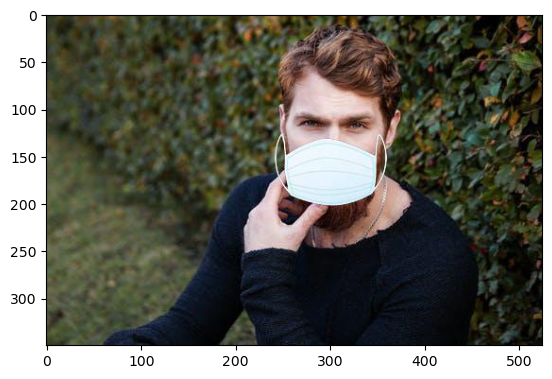

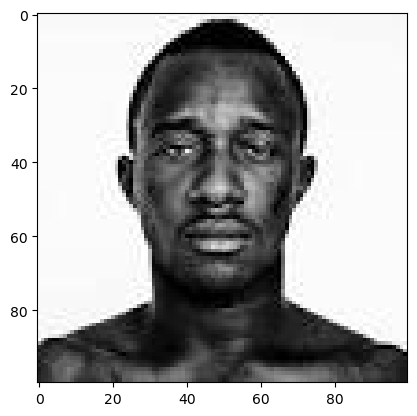

In [14]:
info = {"With Mask":"data/with_mask/with_mask_1.jpg","Without Mask":"data/without_mask/without_mask_1.jpg"}

for i , j in info.items():
    img = mpimg.imread(j)
    imgplot = plt.imshow(img)
    plt.show()

#### **CONCLUSION AT THIS POINT]** Image dimensions are not uniform.

### Image Preprocessing:

1. Resize the images
2. Convert the images to numpy arrays

In [16]:
#Preprocessing for with mask_images:
with_mask_path = "data/with_mask/"

data = []

for img_file in with_mask_files:
    image = Image.open(with_mask_path + img_file)
    image = image.resize((128,128))
    image = image.convert("RGB")
    image = np.array(image)
    data.append(image)





#Preprocessing for without mask_images:
without_mask_path = "data/without_mask/"

for img_file in without_mask_files:
    image = Image.open(without_mask_path + img_file)
    image = image.resize((128,128))
    image = image.convert("RGB")
    image = np.array(image)
    data.append(image)

C:\Users\Lenovo\anaconda3\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
len(data)

7553

In [18]:
type(data)

list

In [19]:
#View the first image (Converted into an numpy array):
data[0]

array([[[50, 58, 31],
        [46, 54, 34],
        [56, 59, 42],
        ...,
        [26, 32, 25],
        [29, 33, 18],
        [34, 40, 16]],

       [[47, 55, 30],
        [49, 57, 37],
        [59, 63, 40],
        ...,
        [18, 21, 11],
        [38, 42, 31],
        [31, 41, 22]],

       [[52, 58, 37],
        [50, 59, 38],
        [59, 64, 36],
        ...,
        [45, 44, 30],
        [29, 35, 28],
        [20, 30, 17]],

       ...,

       [[63, 72, 37],
        [66, 76, 41],
        [74, 84, 50],
        ...,
        [ 5,  4,  0],
        [20, 19, 15],
        [17, 17, 12]],

       [[59, 71, 34],
        [60, 70, 39],
        [68, 76, 50],
        ...,
        [16, 15, 12],
        [15, 13, 10],
        [13,  9,  7]],

       [[53, 69, 29],
        [54, 64, 37],
        [57, 63, 43],
        ...,
        [18, 18, 16],
        [16, 13, 12],
        [20, 12, 13]]], shape=(128, 128, 3), dtype=uint8)

In [20]:
type(data[0])

numpy.ndarray

In [21]:
data[0].shape #height, width and color channel (respectively) of the first image

(128, 128, 3)

### Convert both the data-list and labels into numpy arrays:

In [23]:
X = np.array(data)
Y = np.array(labels)

print(type(X))
print(type(Y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [26]:
print(X.shape) #represents (no. of images (arrays), height of each image individually, width of each image individually, color channel)
print(Y.shape) #no. of labels

(7553, 128, 128, 3)
(7553,)


In [28]:
#Split your data into training and testing data:
X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

In [32]:
#Data before scaling:
X_train[0]

array([[[ 40,  17,  13],
        [ 42,  18,  14],
        [ 46,  20,  16],
        ...,
        [ 45,  29,  30],
        [ 44,  29,  32],
        [ 44,  29,  32]],

       [[ 44,  18,  15],
        [ 47,  21,  17],
        [ 54,  25,  21],
        ...,
        [ 45,  30,  31],
        [ 44,  29,  32],
        [ 44,  29,  32]],

       [[ 53,  23,  18],
        [ 58,  27,  22],
        [ 69,  36,  30],
        ...,
        [ 44,  29,  30],
        [ 43,  28,  31],
        [ 43,  28,  31]],

       ...,

       [[138, 186, 165],
        [135, 186, 164],
        [127, 182, 161],
        ...,
        [177, 120, 111],
        [179, 122, 112],
        [181, 123, 114]],

       [[153, 189, 171],
        [150, 189, 170],
        [145, 188, 168],
        ...,
        [176, 119, 108],
        [178, 121, 109],
        [178, 121, 110]],

       [[158, 196, 177],
        [155, 196, 178],
        [151, 196, 176],
        ...,
        [174, 117, 106],
        [175, 118, 107],
        [175, 118, 107]]

In [33]:
#Scale the data (for making the CNN neural network work better):
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [36]:
#Data after scaling:
X_train_scaled[0]

array([[[0.15686275, 0.06666667, 0.05098039],
        [0.16470588, 0.07058824, 0.05490196],
        [0.18039216, 0.07843137, 0.0627451 ],
        ...,
        [0.17647059, 0.11372549, 0.11764706],
        [0.17254902, 0.11372549, 0.1254902 ],
        [0.17254902, 0.11372549, 0.1254902 ]],

       [[0.17254902, 0.07058824, 0.05882353],
        [0.18431373, 0.08235294, 0.06666667],
        [0.21176471, 0.09803922, 0.08235294],
        ...,
        [0.17647059, 0.11764706, 0.12156863],
        [0.17254902, 0.11372549, 0.1254902 ],
        [0.17254902, 0.11372549, 0.1254902 ]],

       [[0.20784314, 0.09019608, 0.07058824],
        [0.22745098, 0.10588235, 0.08627451],
        [0.27058824, 0.14117647, 0.11764706],
        ...,
        [0.17254902, 0.11372549, 0.11764706],
        [0.16862745, 0.10980392, 0.12156863],
        [0.16862745, 0.10980392, 0.12156863]],

       ...,

       [[0.54117647, 0.72941176, 0.64705882],
        [0.52941176, 0.72941176, 0.64313725],
        [0.49803922, 0

### Building a CNN (Convolutional Neural Network):

In [37]:
import tensorflow as tf
from tensorflow import keras

In [38]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3))) #we used 3 as the last parameter since we also have colored images and not only Gray-scale images
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())


#Create a dense layer:
model.add(keras.layers.Dense(128, activation='relu'))
#Prevent model being over-fitted:
model.add(keras.layers.Dropout(0.5))



#Create an another dense layer:
model.add(keras.layers.Dense(64, activation='relu'))
#Prevent model being over-fitted:
model.add(keras.layers.Dropout(0.5))


#Build the output layer:
model.add(keras.layers.Dense(num_of_classes,activation='sigmoid'))

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
#Compile the neural network:
model.compile(optimizer='adam',
              loss="sparse_categorical_crossentropy",
             metrics=["acc"])

In [41]:
#Train the neural network:

history = model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=5) #Low epochs since dont have large data and giving a large value will result in the model getting overfitted.

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 51s 277ms/step - acc: 0.7901 - loss: 0.4720 - val_acc: 0.9008 - val_loss: 0.2265
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 46s 270ms/step - acc: 0.8858 - loss: 0.2947 - val_acc: 0.9256 - val_loss: 0.1744
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 47s 277ms/step - acc: 0.9068 - loss: 0.2310 - val_acc: 0.9372 - val_loss: 0.1732
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 81s 270ms/step - acc: 0.9215 - loss: 0.2024 - val_acc: 0.9438 - val_loss: 0.1488
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 47s 276ms/step - acc: 0.9343 - loss: 0.1749 - val_acc: 0.9388 - val_loss: 0.1354


### Model Evaluation:

In [43]:
loss , accuracy = model.evaluate(X_test_scaled , Y_test)
print("Test Accuracy = ",accuracy*100,"%")

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - acc: 0.9226 - loss: 0.2055
Test Accuracy =  92.25678443908691 %


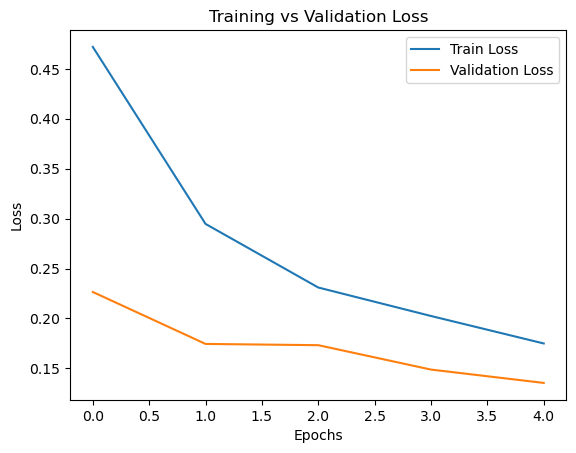

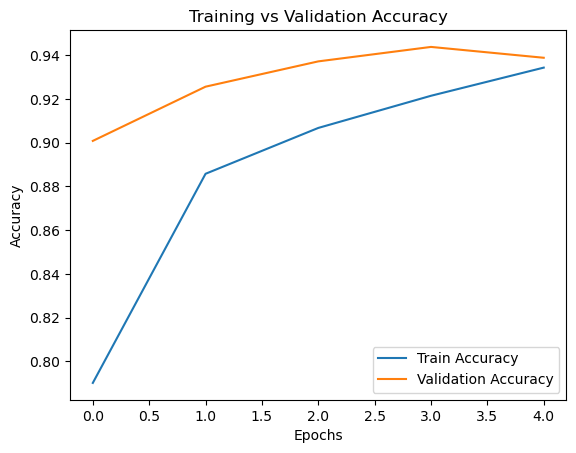

In [47]:
h = history

# Loss graph
plt.plot(h.history['loss'], label='Train Loss')
plt.plot(h.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy graph
plt.plot(h.history['acc'], label='Train Accuracy')
plt.plot(h.history['val_acc'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Make Predictions using the model:

Path of the image to be predicted:  test_image/person.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
[[0.54502964 0.81090623]]
1
The person is wearing a mask


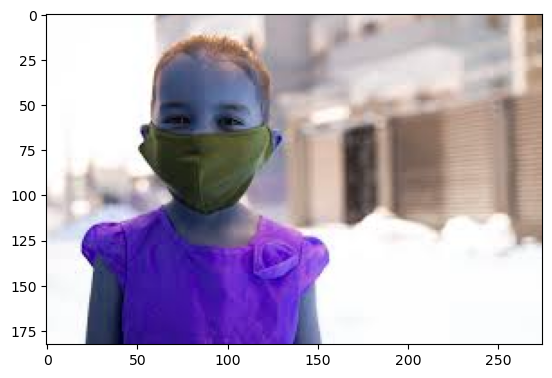

In [50]:
input_image_path = input('Path of the image to be predicted: ')
input_image = cv2.imread(input_image_path)
plt.imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized / 255
input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3]) #Make prediction for one image with dimension as (128,128,3)

input_prediction = model.predict(input_image_reshaped)
print(input_prediction)
input_pred_label = np.argmax(input_prediction)
print(input_pred_label)


if input_pred_label == 1:
    print("The person is wearing a mask")
else:
    print("The person is not wearing mask")

Path of the image to be predicted:  test_image/person2.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[0.59954166 0.399003  ]]
0
The person is not wearing mask


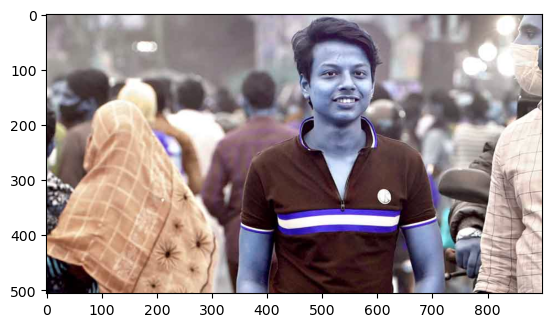

In [51]:
input_image_path = input('Path of the image to be predicted: ')
input_image = cv2.imread(input_image_path)
plt.imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized / 255
input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3]) #Make prediction for one image with dimension as (128,128,3)

input_prediction = model.predict(input_image_reshaped)
print(input_prediction)
input_pred_label = np.argmax(input_prediction)
print(input_pred_label)


if input_pred_label == 1:
    print("The person is wearing a mask")
else:
    print("The person is not wearing mask")

### Deploy the model:

In [52]:
# Save
model.save("model.h5")



### Test the exported model on some new image:

Path of the image to be predicted:  test_image/person3.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
[[0.54064167 0.47327387]]
0
The person is not wearing mask


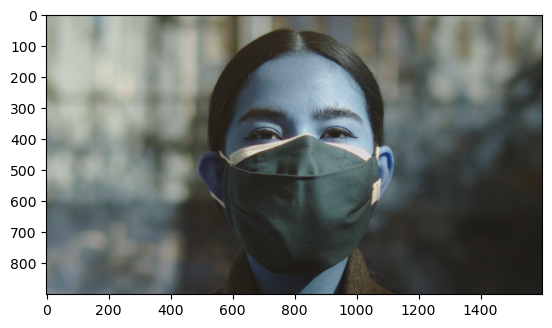

In [53]:
# Load the model and make predictions
from tensorflow.keras.models import load_model
cnn_model = load_model("model.h5")


input_image_path = input('Path of the image to be predicted: ')
input_image = cv2.imread(input_image_path)
plt.imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized / 255
input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3]) #Make prediction for one image with dimension as (128,128,3)

input_prediction = cnn_model.predict(input_image_reshaped)
print(input_prediction)
input_pred_label = np.argmax(input_prediction)
print(input_pred_label)


if input_pred_label == 1:
    print("The person is wearing a mask")
else:
    print("The person is not wearing mask")

Path of the image to be predicted:  test_image/person4.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
[[0.5782794  0.33195263]]
0
The person is not wearing mask


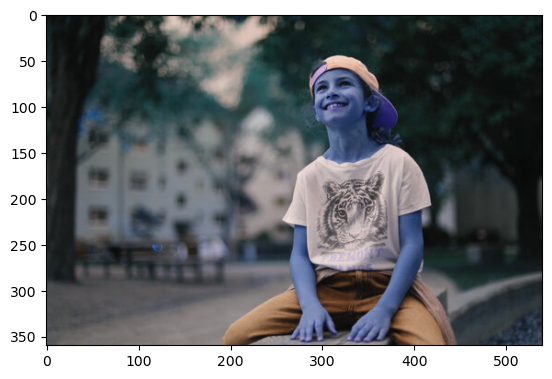

In [54]:
# Load the model and make predictions
from tensorflow.keras.models import load_model
cnn_model = load_model("model.h5")


input_image_path = input('Path of the image to be predicted: ')
input_image = cv2.imread(input_image_path)
plt.imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))
input_image_scaled = input_image_resized / 255
input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3]) #Make prediction for one image with dimension as (128,128,3)

input_prediction = cnn_model.predict(input_image_reshaped)
print(input_prediction)
input_pred_label = np.argmax(input_prediction)
print(input_pred_label)


if input_pred_label == 1:
    print("The person is wearing a mask")
else:
    print("The person is not wearing mask")

### **CONCLUSION AT THIS POINT]** The CNN model made incorrect prediction for the third image and has an accuracy of 94% .

# CONCLUSION] 
This project was demonstrating the use of CNN model to detect whether a person is wearing a face-mask or not.

The accuracy of this model is 94% and it was trained for 5 epochs, and backpropagation was performed 850 times (since 170 * 5) per epoch.

## Project made by:
**Name**: Om Satyawan Pathak <br>
**Email**: omsatyawanpathakgit@gmail.com (or) omsatyawanpathakwebdevelopment@gmail.com <br>
**LinkedIn Profile**: www.linkedin.com/in/om-satyawan-pathak-029b02368 <br>
**Date of project completion**:  30 April 2026 <br>